In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
df = pd.read_csv('pima_diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.info()
df.head()
df.describe()
df.shape
df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [4]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
total_nulls = df.isnull().sum().sum()
total_nulls

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df.drop_duplicates()

In [7]:
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [22]:
cols = ['Glucose', 'BloodPressure','SkinThickness', 'Insulin', 'BMI' ]
for col in cols:
  df[col] = df[col].replace(0, np.nan)
  df[col].fillna(df[col].median(), inplace = True)

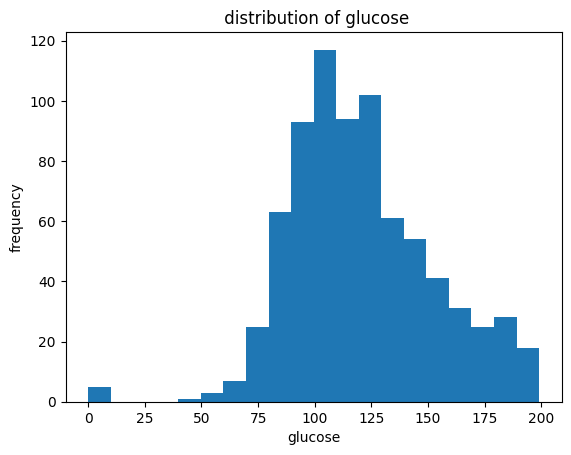

In [8]:
# histogram of glucose

plt.figure()
plt.hist(df['Glucose'], bins = 20)
plt.title(" distribution of glucose")
plt.xlabel("glucose")
plt.ylabel("frequency")
plt.show()

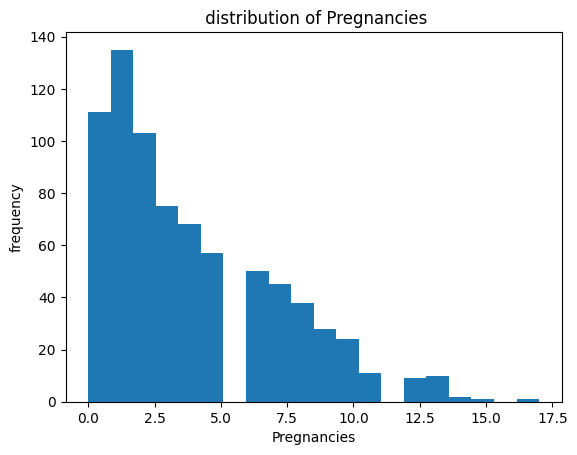

In [9]:
# histogram of pregnancies

plt.figure()
plt.hist(df['Pregnancies'], bins = 20)
plt.title(" distribution of Pregnancies")
plt.xlabel("Pregnancies")
plt.ylabel("frequency")
plt.show()

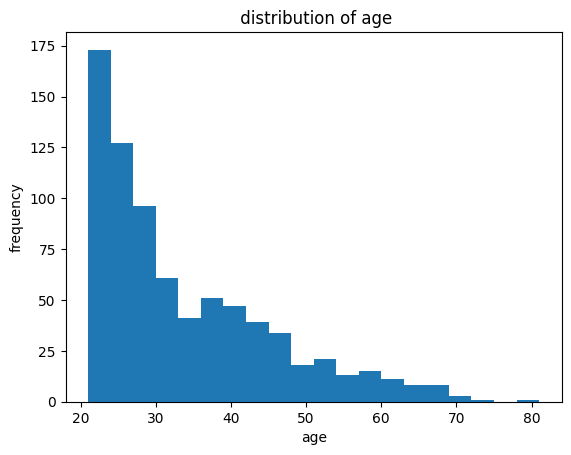

In [10]:
# histogram of Age

plt.figure()
plt.hist(df['Age'], bins = 20)
plt.title(" distribution of age")
plt.xlabel("age")
plt.ylabel("frequency")
plt.show()

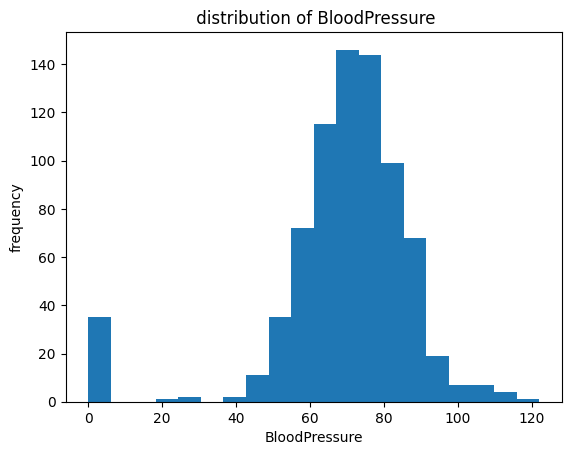

In [11]:
# histogram of BloodPressure

plt.figure()
plt.hist(df['BloodPressure'], bins = 20)
plt.title(" distribution of BloodPressure")
plt.xlabel("BloodPressure")
plt.ylabel("frequency")
plt.show()

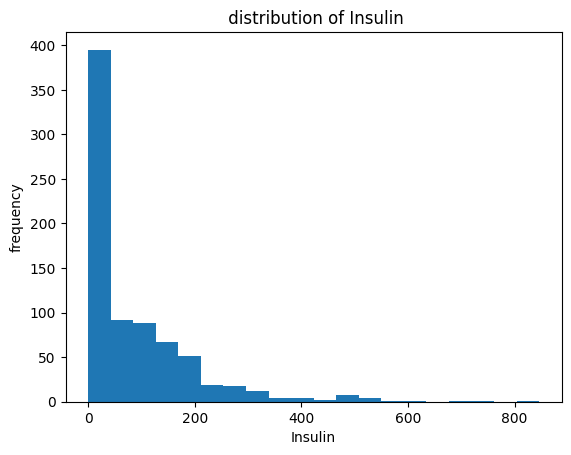

In [12]:
# histogram of Insulin

plt.figure()
plt.hist(df['Insulin'], bins = 20)
plt.title(" distribution of Insulin")
plt.xlabel("Insulin")
plt.ylabel("frequency")
plt.show()

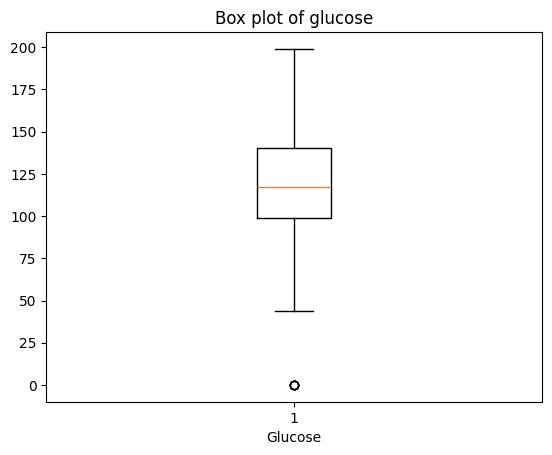

In [13]:
# box plot of glucose

plt.figure()
plt.boxplot(df['Glucose'])
plt.title("Box plot of glucose")
plt.xlabel("Glucose")
plt.show()

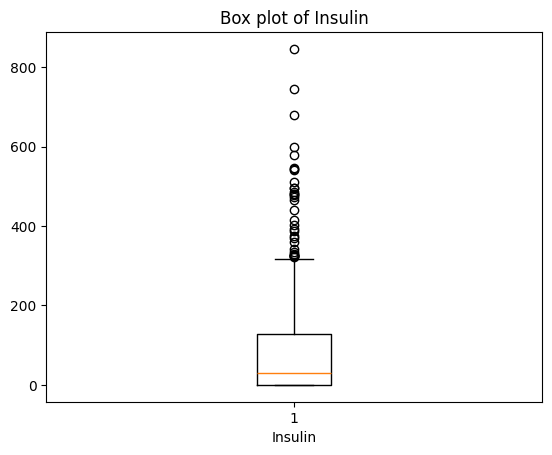

In [14]:
# box plot of Insulin

plt.figure()
plt.boxplot(df['Insulin'])
plt.title("Box plot of Insulin")
plt.xlabel("Insulin")
plt.show()

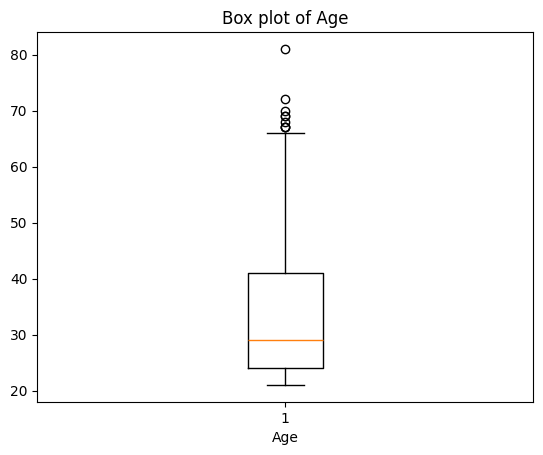

In [15]:
# box plot of age

plt.figure()
plt.boxplot(df['Age'])
plt.title("Box plot of Age")
plt.xlabel("Age")
plt.show()

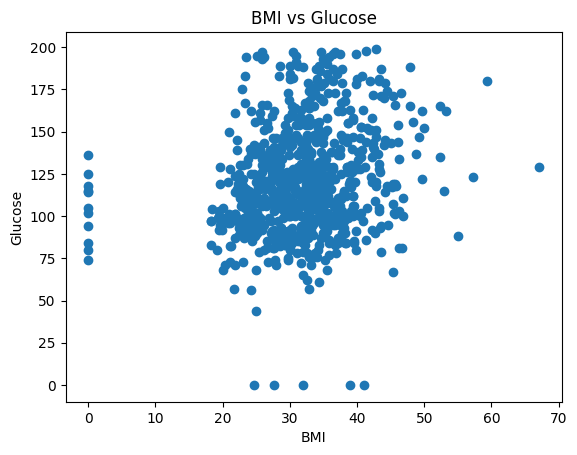

In [16]:
# scatter plot

plt.figure()
plt.scatter(df['BMI'],df['Glucose'])
plt.xlabel("BMI")
plt.ylabel("Glucose")
plt.title("BMI vs Glucose")
plt.show()

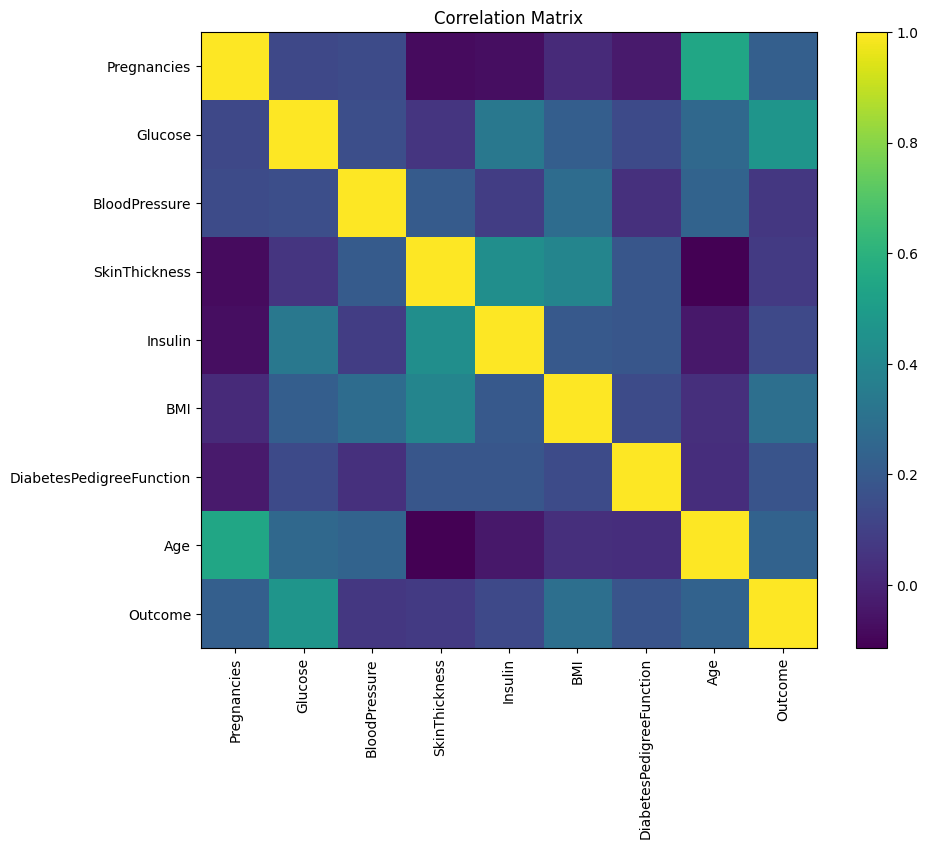

In [17]:
#  Correlation Heatmap
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

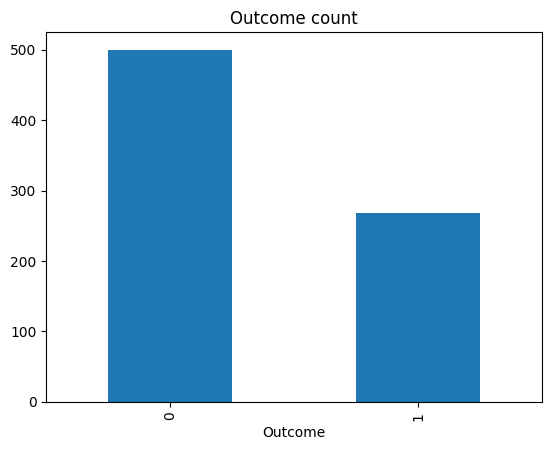

In [18]:
# bar - Outcome count
plt.figure()
df['Outcome'].value_counts().sort_index().plot(kind='bar')
plt.title("Outcome count")
plt.show()